In [47]:
import vbjax as vb
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time
import sys
import os
import pandas as pd
import seaborn as sns
import tqdm
import jax.example_libraries.optimizers as jopt
from jax.scipy.special import kl_div
import networkx as nx
from copy import deepcopy
from scipy.stats import ks_2samp, entropy

In [48]:
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)
import mpr_jax
import FCD_jax
import utils
from importlib import reload
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

In [49]:
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform" 
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
os.environ["JAX_ENABLE_X64"] = "True"

In [50]:
%matplotlib inline

## upload data and parameters, g_target = 0.33

In [51]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(os.path.join(datapath, "weights.txt"))
weights = weights#[:10,:10]
nn = len(weights)
SC = jnp.array(weights) / jnp.max(weights)

true_g = 0.33

weights=SC
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0, # set to 500 to subsaple BOLD
          "seed":42
          }

wwidth = 30  # must be < 60
maxNwindows = 300
olap = 0.94
cut = 50 #number of initial time points discarded from the BOLD signal (if BOLD was subsampled, discard 20 or 50 only)
tr = 1

g_values = np.arange(0., 1.5, 0.05) #normally the step is 0.05 instead of 2

In [52]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [53]:
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 54.48 seconds


In [54]:
FC = np.corrcoef(bold_d[cut:].T) #[cut:]

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap) #[cut::tr]
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]
#u_FCD = FCD[jnp.triu_indices_from(FCD, k=1)]

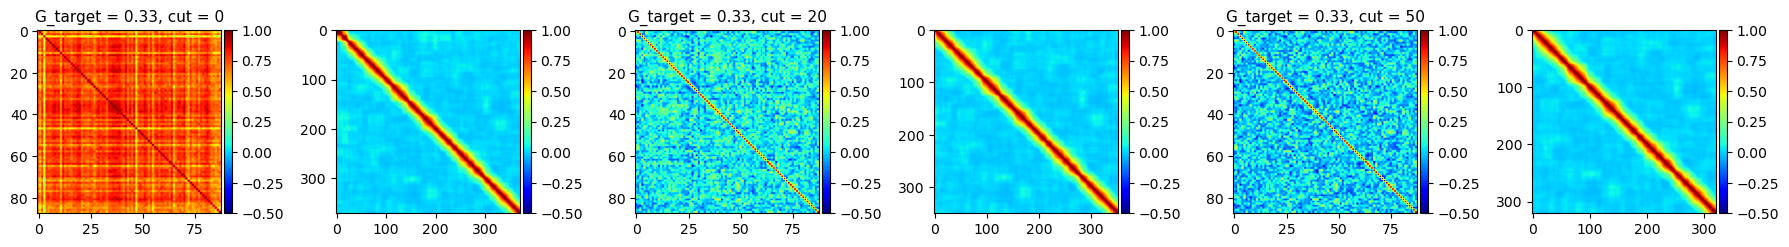

Saved figure to: /mnt/user/drive/My Libraries/My Library/GSoC/results/2025-11-19/FC_FCD_examples_g_target_0.33_cut_0_20_50_subsampled_t_end_200000.png


In [55]:
cuts = [0, 20, 50]   # starting points
g_true = true_g      # your target G value

fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(18, 4))

for idx, cut in enumerate(cuts):
    # ---- Compute FC & FCD ----
    FC  = np.corrcoef(bold_d[cut:].T)
    FCD, FCvec, _ = FCD_jax.extract_FCD(
        bold_d[cut:].T,
        wwidth=wwidth,
        maxNwindows=maxNwindows,
        olap=olap
    )

    # ----- Left subplot of pair: FC -----
    ax_fc = axes[2*idx]
    im_fc = ax_fc.imshow(FC, vmin=-0.5, vmax=1, cmap='jet')

    # Colorbar matching height
    cax_fc = ax_fc.inset_axes([1.02, 0., 0.04, 1])
    fig.colorbar(im_fc, cax=cax_fc)

    # Title for this FC/FCD pair
    ax_fc.set_title(f"G_target = {g_true}, cut = {cut}", fontsize=11)

    # ----- Right subplot of pair: FCD -----
    ax_fcd = axes[2*idx + 1]
    im_fcd = ax_fcd.imshow(FCD, vmin=-0.5, vmax=1, cmap='jet')

    # Colorbar matching height
    cax_fcd = ax_fcd.inset_axes([1.02, 0., 0.04, 1])
    fig.colorbar(im_fcd, cax=cax_fcd)

plt.tight_layout()

save_path = (
    utils.results_folder() +
    f"/FC_FCD_examples_g_target_{true_g}_cut_0_20_50_subsampled_t_end_{params['t_end']}.png"
)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print("Saved figure to:", save_path)

### simulator, fix g_target = 0.33, cut = 50 and sweep over parameters

In [56]:
@timer
def wrapper_with_key(g, key, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    #par["seed"] = seed
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par,key)
    data = sde.run({'G':g})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [57]:
def run_for_prms_mod(G,key) :

    rv_t, r, v, bold_t, bold_d = wrapper_with_key(G, key, params)

    sim_fc = FCD_jax.get_fc(bold_d[cut:].T) #[cut:]

    sim_fcd, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap) #[cut::tr]

    sim_u_FC = sim_fc[jnp.triu_indices_from(sim_fc, k=1)]
    sim_zu_FC = (sim_u_FC - np.mean(sim_u_FC)) / np.std(sim_u_FC)
    sim_u_FCD = sim_fcd[jnp.triu_indices_from(sim_fcd, k=30)]
    
    return sim_u_FC, sim_zu_FC, sim_u_FCD

In [58]:
def try_loss_mod_extended(prm, FC_obs_flat, FC_obs_zsco_flat, FCD_obs_flat, key, wwidth=30, olap=0.94, bins=50):
    """
    Compute multiple loss components between simulated and observed FC/FCD.
    """

    losses = {}
    #sim_bold, sim_fc, sim_fcd = run_for_prms_mod(prm, key)
    sim_u_FC, sim_zu_FC, sim_u_FCD = run_for_prms_mod(prm, key)
    
    # mean FC difference
    #losses["mean_fc"] = float((np.mean(obs_fc_np) - np.mean(sim_fc_np)) ** 2)
    losses["mean_fc"] = float((np.mean(FC_obs_flat) - np.mean(sim_u_FC)) ** 2)
    
    # correlation of FC patterns
    r = np.corrcoef(sim_zu_FC, FC_obs_zsco_flat)[0, 1]
    losses["corr_fc"] = float(np.nan_to_num(r, nan=0.0))
    
    # MSE of FC
    losses["mse_fc"] = float(np.mean((FC_obs_flat - sim_u_FC) ** 2))

    # KS distance
    losses["ks_fc"] = float(ks_2samp(FC_obs_flat, sim_u_FC)[0])

    # histogram-based KL divergence
    eps = 1e-8
    p_hist, edges = np.histogram(FC_obs_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_u_FC, bins=edges, density=True)
    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fc_hist"] = float(entropy(p, q))
   
    # variance difference
    losses["var_fcd"] = float((np.var(FCD_obs_flat) - np.var(sim_u_FCD)) ** 2)
    losses["ks_fcd"] = float(ks_2samp(FCD_obs_flat, sim_u_FCD)[0])
    
    # Histogram-based KL for FCD (only on selected upper triangle values)
    eps = 1e-8
    p_hist, edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    q_hist, _ = np.histogram(sim_u_FCD, bins=edges, density=True)

    p = (p_hist + eps) / (p_hist + eps).sum()
    q = (q_hist + eps) / (q_hist + eps).sum()
    losses["kl_fcd_hist"] = float(entropy(p, q))

    return losses

In [30]:
loss_sweep_mod_extended = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    loss = try_loss_mod_extended(g, u_FC, zu_FC, u_FCD, key)
    for key in loss_sweep_mod_extended.keys() :
        loss_sweep_mod_extended[key].append(loss[key])

wrapper_with_key took 54.77 seconds
0.0 400
wrapper_with_key took 51.68 seconds
0.05 400
wrapper_with_key took 56.20 seconds
0.1 400
wrapper_with_key took 57.63 seconds
0.15000000000000002 400
wrapper_with_key took 59.41 seconds
0.2 400
wrapper_with_key took 59.17 seconds
0.25 400
wrapper_with_key took 60.16 seconds
0.30000000000000004 400
wrapper_with_key took 57.17 seconds
0.35000000000000003 400
wrapper_with_key took 56.55 seconds
0.4 400
wrapper_with_key took 60.65 seconds
0.45 400
wrapper_with_key took 59.11 seconds
0.5 400
wrapper_with_key took 60.18 seconds
0.55 400
wrapper_with_key took 53.48 seconds
0.6000000000000001 400
wrapper_with_key took 55.98 seconds
0.65 400
wrapper_with_key took 56.53 seconds
0.7000000000000001 400
wrapper_with_key took 56.27 seconds
0.75 400
wrapper_with_key took 55.53 seconds
0.8 400
wrapper_with_key took 56.29 seconds
0.8500000000000001 400
wrapper_with_key took 56.78 seconds
0.9 400
wrapper_with_key took 59.06 seconds
0.9500000000000001 400
wrappe

In [31]:
for key in loss_sweep_mod_extended.keys() :
    loss_sweep_mod_extended[key] = np.array(loss_sweep_mod_extended[key])

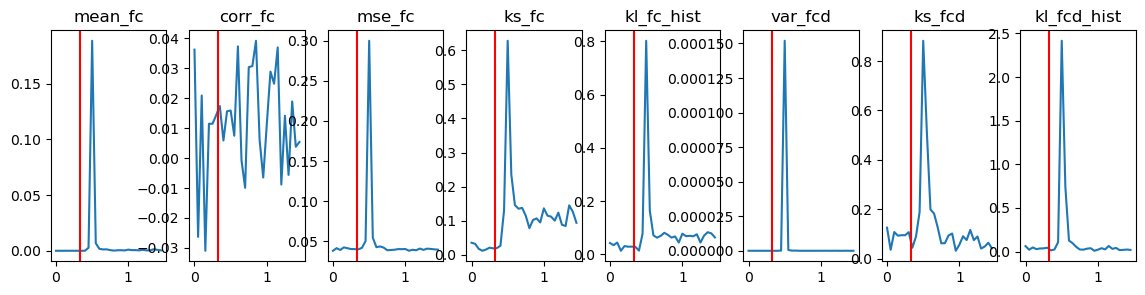

In [34]:
fig, ax = plt.subplots(ncols=len(loss_sweep_mod_extended), figsize=(14, 3))
for i, (k,v) in enumerate(loss_sweep_mod_extended.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(true_g, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### take average on every g of the sweep to smooth loss

In [59]:
def try_loss_mod_extended_vmap(
        prm,
        FC_obs_flat,
        FC_obs_zsco_flat,
        FCD_obs_flat,
        n_sims=10,
        wwidth=30,
        olap=0.94,
        bins=50):

    """
    Compute losses between observed FC/FCD and simulated FC/FCD,
    averaging (actually summing) over many random seeds.

    Inputs are already flattened, so no triangular extraction is done here.
    """

    eps = 1e-8

    # Random keys
    base_key = jax.random.PRNGKey(int(time.time()))
    keys = jax.random.split(base_key, n_sims)

    # Vectorize simulation
    def run_once(key):
        sim_u_FC, sim_zu_FC, sim_u_FCD = run_for_prms_mod(prm, key)
        return sim_u_FC, sim_zu_FC, sim_u_FCD

    sim_u_FC_all, sim_zu_FC_all, sim_u_FCD_all = jax.vmap(run_once)(keys)

    # Move to numpy
    sim_u_FC_all = np.array(sim_u_FC_all)
    sim_zu_FC_all = np.array(sim_zu_FC_all)
    sim_u_FCD_all = np.array(sim_u_FCD_all)

    # Prepare histograms for obs
    p_fc_hist, fc_edges = np.histogram(FC_obs_flat, bins=bins, density=True)
    p_fc = (p_fc_hist + eps) / (p_fc_hist + eps).sum()

    p_fcd_hist, fcd_edges = np.histogram(FCD_obs_flat, bins=bins, density=True)
    p_fcd = (p_fcd_hist + eps) / (p_fcd_hist + eps).sum()

    # --- initialize losses ---
    losses = {
        "mean_fc": 0.0,
        "corr_fc": 0.0,
        "mse_fc": 0.0,
        "ks_fc": 0.0,
        "kl_fc_hist": 0.0,
        "var_fcd": 0.0,
        "ks_fcd": 0.0,
        "kl_fcd_hist": 0.0,
    }

    # --- Loop only on simulations for loss aggregation ---
    for sim_u_FC, sim_zu_FC, sim_u_FCD in zip(sim_u_FC_all, sim_zu_FC_all, sim_u_FCD_all):

        # FC mean
        losses["mean_fc"] += (np.mean(FC_obs_flat) - np.mean(sim_u_FC)) ** 2

        # FC correlation
        r = np.corrcoef(sim_zu_FC, FC_obs_zsco_flat)[0, 1]
        losses["corr_fc"] += np.nan_to_num(r, nan=0.0)

        # FC MSE
        losses["mse_fc"] += np.mean((FC_obs_flat - sim_u_FC) ** 2)

        # FC KS
        losses["ks_fc"] += ks_2samp(FC_obs_flat, sim_u_FC)[0]

        # FC KL
        q_hist, _ = np.histogram(sim_u_FC, bins=fc_edges, density=True)
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fc_hist"] += entropy(p_fc, q)

        # FCD variance
        losses["var_fcd"] += (np.var(FCD_obs_flat) - np.var(sim_u_FCD)) ** 2

        # FCD KS
        losses["ks_fcd"] += ks_2samp(FCD_obs_flat, sim_u_FCD)[0]

        # FCD KL
        q_hist, _ = np.histogram(sim_u_FCD, bins=fcd_edges, density=True)
        q = (q_hist + eps) / (q_hist + eps).sum()
        losses["kl_fcd_hist"] += entropy(p_fcd, q)

    return losses

### g_target = 0.33

In [ ]:
losses = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses.keys() :
        losses[key].append(loss[key])

wrapper_with_key took 280.92 seconds
wrapper_with_key took 273.43 seconds
wrapper_with_key took 265.12 seconds
wrapper_with_key took 261.68 seconds
wrapper_with_key took 268.94 seconds
wrapper_with_key took 260.26 seconds
wrapper_with_key took 266.32 seconds
wrapper_with_key took 273.94 seconds
wrapper_with_key took 267.62 seconds
wrapper_with_key took 274.08 seconds
wrapper_with_key took 270.26 seconds
wrapper_with_key took 256.25 seconds
wrapper_with_key took 270.31 seconds
wrapper_with_key took 272.10 seconds
wrapper_with_key took 266.04 seconds
wrapper_with_key took 262.18 seconds
wrapper_with_key took 253.00 seconds
wrapper_with_key took 266.50 seconds
wrapper_with_key took 268.85 seconds


In [ ]:
for key in losses.keys() :
    losses[key] = np.array(losses[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses), figsize=(14, 3))
for i, (k,v) in enumerate(losses.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.33, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0

In [76]:
true_g = 0.0
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 64.57 seconds


In [77]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [ ]:
losses0 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss0 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses0.keys() :
        losses0[key].append(loss0[key])

wrapper_with_key took 270.68 seconds
wrapper_with_key took 268.37 seconds
wrapper_with_key took 278.30 seconds
wrapper_with_key took 276.35 seconds
wrapper_with_key took 287.27 seconds
wrapper_with_key took 279.44 seconds
wrapper_with_key took 269.73 seconds
wrapper_with_key took 277.25 seconds
wrapper_with_key took 272.97 seconds
wrapper_with_key took 278.22 seconds
wrapper_with_key took 272.34 seconds
wrapper_with_key took 276.26 seconds
wrapper_with_key took 273.24 seconds
wrapper_with_key took 279.14 seconds
wrapper_with_key took 275.44 seconds
wrapper_with_key took 278.54 seconds
wrapper_with_key took 269.60 seconds
wrapper_with_key took 276.45 seconds
wrapper_with_key took 268.89 seconds
wrapper_with_key took 276.14 seconds
wrapper_with_key took 279.00 seconds
wrapper_with_key took 276.67 seconds
wrapper_with_key took 274.52 seconds
wrapper_with_key took 278.47 seconds
wrapper_with_key took 274.44 seconds
wrapper_with_key took 275.62 seconds
wrapper_with_key took 275.20 seconds
w

In [ ]:
for key in losses0.keys() :
    losses0[key] = np.array(losses0[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses0), figsize=(14, 3))
for i, (k,v) in enumerate(losses0.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.0, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0.5

In [60]:
true_g = 0.5
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

wrapper took 63.29 seconds


In [61]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [ ]:
losses05 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss05 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses05.keys() :
        losses05[key].append(loss05[key])

wrapper_with_key took 263.55 seconds
wrapper_with_key took 265.02 seconds
wrapper_with_key took 260.95 seconds
wrapper_with_key took 262.36 seconds
wrapper_with_key took 262.48 seconds
wrapper_with_key took 258.63 seconds
wrapper_with_key took 270.09 seconds
wrapper_with_key took 267.24 seconds
wrapper_with_key took 268.77 seconds
wrapper_with_key took 268.96 seconds
wrapper_with_key took 272.53 seconds
wrapper_with_key took 268.15 seconds
wrapper_with_key took 266.12 seconds
wrapper_with_key took 263.96 seconds
wrapper_with_key took 271.18 seconds
wrapper_with_key took 266.91 seconds
wrapper_with_key took 275.15 seconds
wrapper_with_key took 273.00 seconds
wrapper_with_key took 262.91 seconds


In [ ]:
for key in losses05.keys() :
    losses05[key] = np.array(losses05[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses05), figsize=(14, 3))
for i, (k,v) in enumerate(losses05.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.5, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)

### g_target = 0.7

In [ ]:
true_g = 0.7
params = {"G": true_g, 
          "weights": weights,
          "t_end": 200000, #t_end 300_000, cut 10_000, tr 500
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 500.0, # set to 500 to subsaple BOLD
          "seed":42
          }
rv_t, r, v, bold_t, bold_d =  wrapper(true_g, params)

In [ ]:
FC = np.corrcoef(bold_d[cut:].T)

FCD, FCvec,_ = FCD_jax.extract_FCD(bold_d.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
BOLD = bold_d

u_FC = FC[jnp.triu_indices_from(FC, k=1)]
zu_FC = (u_FC - np.mean(u_FC)) / np.std(u_FC)
u_FCD = FCD[jnp.triu_indices_from(FCD, k=30)]

In [ ]:
losses07 = {
    'mean_fc': [],
    'corr_fc': [],
    'mse_fc': [],
    'ks_fc': [],
    'kl_fc_hist': [],
    'var_fcd': [],
    'ks_fcd': [],
    'kl_fcd_hist': []
}

for g in g_values :
    loss07 = try_loss_mod_extended_vmap(g, u_FC, zu_FC, u_FCD)
    for key in losses07.keys() :
        losses07[key].append(loss07[key])

In [ ]:
for key in losses07.keys() :
    losses07[key] = np.array(losses07[key])

In [ ]:
fig, ax = plt.subplots(ncols=len(losses07), figsize=(14, 3))
for i, (k,v) in enumerate(losses07.items()) :
    ax[i].plot(g_values, v)
    ax[i].axvline(0.7, color='r')
    min_index = np.argmin(v)
    #ax[i].axvline(g_values[min_index], color='g')
    ax[i].set(title=k)